# Iloilo Daily Weather Forecast (LSTM-Only) — **Training Notebook (Revised, 2-Day Direct Forecast)**

This template is a **clean revised version** of your training notebook, tailored to your goal:

- Predict **next 2 days** of daily weather parameters for **Iloilo City**
- Use **LSTM only** (no hybrid model)
- Improve methodology and metrics reliability (R² / MAE / RMSE)

## Key fixes included
- ✅ **Direct 2-day forecasting** (multi-horizon output) instead of only 1-step
- ✅ **No leakage**: scalers are fit on **train only**
- ✅ **Correct evaluation alignment** (no `actual[:-1]` vs `pred[1:]`)
- ✅ **Train/val/test split is chronological**
- ✅ **Larger validation windows / proper walk-forward backtesting**
- ✅ **Calendar seasonality features** (sin/cos)
- ✅ **Rain transform** using `log1p` (helps spikes)
- ✅ **Config/scalers/model saved consistently** for inference notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Install Requirements (Colab)

In [ ]:
# Uncomment if running in Google Colab
!pip install openmeteo-requests requests-cache retry-requests keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.3/707.3 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.9 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


## 2) Imports

In [ ]:
import os
import json
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import requests_cache
from retry_requests import retry
import openmeteo_requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber, MeanSquaredError

import joblib

# Optional tuner (required only if RUN_HYPERPARAM_TUNING=True)
try:
    import keras_tuner as kt
except ImportError:
    kt = None
    print("keras_tuner not installed. Install it if you want hyperparameter tuning.")

## 3) Plot Style (optional)

In [ ]:
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 11,
})

## 4) Config / Constants

In [ ]:
# =========================
# PROJECT / PATHS
# =========================
# If using Colab + Drive, mount first:
# from google.colab import drive
# drive.mount('/content/drive')

USE_COLAB_DRIVE = True  # set True if using Google Drive paths below

if USE_COLAB_DRIVE:
    BASE_DIR = "/content/drive/MyDrive/THESIS/THESIS Google Colab/Models"
else:
    BASE_DIR = "./models"

PROJ_NAME = "iloilo_lstm_daily_weather_direct2_x14"
PROJECT_PATH = os.path.join(BASE_DIR, PROJ_NAME)
ARTIFACT_DIR = os.path.join(PROJECT_PATH, "artifacts")
FINAL_MODEL_DIR = os.path.join(PROJECT_PATH, "final_model")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(FINAL_MODEL_DIR, "LSTM_Weather_Forecast_Direct2.keras")
X_SCALER_PATH = os.path.join(FINAL_MODEL_DIR, "x_scaler.pkl")
Y_SCALER_PATH = os.path.join(FINAL_MODEL_DIR, "y_scaler.pkl")
CONFIG_PATH = os.path.join(FINAL_MODEL_DIR, "config.json")

# =========================
# LOCATION / DATA
# =========================
LATITUDE = 10.6969
LONGITUDE = 122.5644
TIMEZONE = "Asia/Manila"  # use local timezone explicitly
TRAIN_START_DATE = "2014-01-01"
TRAIN_END_DATE = "2024-12-31"   # adjust if needed

# =========================
# MODELING GOAL
# =========================
TARGET_HORIZON = 2  # predict next 2 days
N_STEPS = 7        # try 7, 14, 21, 30 later (recommended tuning target)

# =========================
# SPLITS (chronological by target date)
# =========================
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

# =========================
# TRAINING
# =========================
SEED = 42
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
USE_HUBER_LOSS = False  # often better than MSE for rain spikes

# =========================
# HYPERPARAMETER TUNING + TSCV (optional but enabled by default here)
# =========================
RUN_HYPERPARAM_TUNING = True
TUNER_OVERWRITE = True
TUNER_MAX_TRIALS = 150             # requested
TUNER_EPOCHS = 40                   # per fold during tuning (keep lower than final training)
TUNER_BATCH_SIZE = BATCH_SIZE
TSCV_N_SPLITS = 5                   # requested
TSCV_TEST_SIZE = 30                 # validation window per fold (daily samples); more stable than 2
TSCV_PATIENCE = 5
TUNER_DIR = os.path.join(ARTIFACT_DIR, "keras_tuner")
TUNER_PROJECT_NAME = f"direct2_tscv_bayesopt_150trials"
os.makedirs(TUNER_DIR, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Core target variables (same as your project)
TARGET_COLS_RAW = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum",
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",  # stored in hours after preprocessing
]

FEATURE_DISPLAY_NAMES = [
    "Min Temperature",
    "Max Temperature",
    "Rain Sum",
    "Mean Wind Speed",
    "Mean Relative Humidity",
    "Mean Dew Point",
    "Sunshine Duration",
]

## 5) Utility Functions (Fetch, Preprocess, Feature Engineering)

In [ ]:
def fetch_openmeteo_daily_archive(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    timezone: str = "Asia/Manila",
) -> pd.DataFrame:
    """Fetch daily historical weather from Open-Meteo archive API."""
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_min",
            "temperature_2m_max",
            "rain_sum",
            "wind_speed_10m_mean",
            "relative_humidity_2m_mean",
            "dew_point_2m_mean",
            "sunshine_duration",
        ],
        "timezone": timezone,  # local timezone to reduce date confusion
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    daily = response.Daily()

    data = {
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time(), unit="s", utc=True),
            end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left",
        ),
        "temperature_2m_min": daily.Variables(0).ValuesAsNumpy(),
        "temperature_2m_max": daily.Variables(1).ValuesAsNumpy(),
        "rain_sum": daily.Variables(2).ValuesAsNumpy(),
        "wind_speed_10m_mean": daily.Variables(3).ValuesAsNumpy(),
        "relative_humidity_2m_mean": daily.Variables(4).ValuesAsNumpy(),
        "dew_point_2m_mean": daily.Variables(5).ValuesAsNumpy(),
        "sunshine_duration": daily.Variables(6).ValuesAsNumpy(),  # seconds from API
    }

    df = pd.DataFrame(data)
    return df


def add_calendar_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Cyclical calendar features for seasonality."""
    # convert to local timezone for day-of-year interpretation
    idx_local = index.tz_convert(TIMEZONE) if index.tz is not None else index.tz_localize(TIMEZONE)
    day_of_year = idx_local.dayofyear.astype(float)
    month = idx_local.month.astype(float)

    cal = pd.DataFrame(index=index)
    cal["doy_sin"] = np.sin(2 * np.pi * day_of_year / 366.0)
    cal["doy_cos"] = np.cos(2 * np.pi * day_of_year / 366.0)
    cal["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    cal["month_cos"] = np.cos(2 * np.pi * month / 12.0)
    return cal


def preprocess_daily_weather(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess raw Open-Meteo daily data into modeling-ready dataframe."""
    df = raw_df.copy()

    # Ensure datetime + timezone handling
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df = df.sort_values("date").drop_duplicates("date")
    df = df.set_index("date")

    # Convert sunshine seconds -> hours
    df["sunshine_duration"] = df["sunshine_duration"] / 3600.0

    # Fill missing sunshine using time interpolation (keep your original idea)
    if "sunshine_duration" in df.columns:
        df["sunshine_duration"] = df["sunshine_duration"].interpolate(method="time").bfill().ffill()

    # Basic cleaning: avoid negatives for variables that should be non-negative
    df["rain_sum"] = df["rain_sum"].clip(lower=0)
    df["sunshine_duration"] = df["sunshine_duration"].clip(lower=0)

    # Optional rain transform for better learning on spikes
    df["rain_sum_log1p"] = np.log1p(df["rain_sum"])

    # Add calendar features
    cal = add_calendar_features(df.index)
    df = pd.concat([df, cal], axis=1)

    # Drop any remaining missing rows
    df = df.dropna().copy()
    return df


def inverse_target_postprocess(y_pred_target_raw: np.ndarray, target_cols_transformed: List[str]) -> np.ndarray:
    """Convert transformed target columns back to original physical units (rain expm1, clipping)."""
    out = pd.DataFrame(y_pred_target_raw, columns=target_cols_transformed)

    # Reverse rain transform
    if "rain_sum_log1p" in out.columns:
        out["rain_sum"] = np.expm1(out["rain_sum_log1p"]).clip(lower=0)
        out = out.drop(columns=["rain_sum_log1p"])

    # Physical clipping / sanity
    if "sunshine_duration" in out.columns:
        out["sunshine_duration"] = out["sunshine_duration"].clip(lower=0)
    if "relative_humidity_2m_mean" in out.columns:
        out["relative_humidity_2m_mean"] = out["relative_humidity_2m_mean"].clip(lower=0, upper=100)
    if "rain_sum" in out.columns:
        out["rain_sum"] = out["rain_sum"].clip(lower=0)

    # Enforce max temp >= min temp (optional but practical)
    if {"temperature_2m_min", "temperature_2m_max"}.issubset(out.columns):
        mask = out["temperature_2m_max"] < out["temperature_2m_min"]
        if mask.any():
            swapped_max = out.loc[mask, "temperature_2m_min"].values
            out.loc[mask, "temperature_2m_min"] = out.loc[mask, "temperature_2m_max"].values
            out.loc[mask, "temperature_2m_max"] = swapped_max

    # Return in raw target order
    final_cols = [
        "temperature_2m_min",
        "temperature_2m_max",
        "rain_sum",
        "wind_speed_10m_mean",
        "relative_humidity_2m_mean",
        "dew_point_2m_mean",
        "sunshine_duration",
    ]
    return out[final_cols].to_numpy()

def display_history(hist):
  hist = pd.DataFrame(hist.history)
  display(hist.tail())

  for metric in ["loss", "mae", "rmse"]:
      plt.figure(figsize=(10,4))
      plt.plot(hist[metric], label=f"train_{metric}")
      if f"val_{metric}" in hist.columns:
          plt.plot(hist[f"val_{metric}"], label=f"val_{metric}")
      plt.title(f"Training Curve - {metric.upper()}")
      plt.xlabel("Epoch")
      plt.ylabel(metric.upper())
      plt.legend()
      plt.show()

## 6) Sequence Creation + Splitting Helpers

In [ ]:
def create_multihorizon_sequences(
    X_scaled: np.ndarray,
    y_scaled: np.ndarray,
    dates_index: pd.DatetimeIndex,
    n_steps: int,
    horizon: int,
):
    """
    Create direct multi-horizon sequences.
    X_seq shape: (n_samples, n_steps, n_features)
    y_seq shape: (n_samples, horizon, n_targets)

    target_dates[i] = array of length horizon with the actual dates for y_seq[i]
    """
    X_seq, y_seq, target_dates = [], [], []

    n_rows = len(X_scaled)
    for start in range(n_rows - n_steps - horizon + 1):
        end_x = start + n_steps
        end_y = end_x + horizon

        X_seq.append(X_scaled[start:end_x])
        y_seq.append(y_scaled[end_x:end_y])
        target_dates.append(dates_index[end_x:end_y])

    return np.asarray(X_seq), np.asarray(y_seq), np.asarray(target_dates, dtype=object)


def chronological_row_splits(n_rows: int, train_ratio: float, val_ratio: float, test_ratio: float):
    assert n_rows > 10
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)
    # test gets the remainder
    return train_end, val_end


def fit_scalers_on_train_only(
    df_model: pd.DataFrame,
    feature_cols_model: List[str],
    target_cols_model: List[str],
    train_end_row: int,
):
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    x_scaler.fit(df_model.iloc[:train_end_row][feature_cols_model].values)
    y_scaler.fit(df_model.iloc[:train_end_row][target_cols_model].values)

    X_scaled = x_scaler.transform(df_model[feature_cols_model].values)
    y_scaled = y_scaler.transform(df_model[target_cols_model].values)

    return X_scaled, y_scaled, x_scaler, y_scaler


def split_sequences_by_target_date(
    X_seq: np.ndarray,
    y_seq: np.ndarray,
    target_dates: np.ndarray,
    train_end_date: pd.Timestamp,
    val_end_date: pd.Timestamp,
):
    """
    Split sequence samples based on the FIRST target date (horizon-1 date can spill within same partition).
    """
    first_target_dates = pd.to_datetime([td[0] for td in target_dates])

    train_mask = first_target_dates <= train_end_date
    val_mask = (first_target_dates > train_end_date) & (first_target_dates <= val_end_date)
    test_mask = first_target_dates > val_end_date

    splits = {
        "train": (X_seq[train_mask], y_seq[train_mask], target_dates[train_mask]),
        "val": (X_seq[val_mask], y_seq[val_mask], target_dates[val_mask]),
        "test": (X_seq[test_mask], y_seq[test_mask], target_dates[test_mask]),
    }
    return splits

## 7) Model Builder (LSTM-Only, Direct 2-Day Output)

In [ ]:
@tf.keras.utils.register_keras_serializable()
class R2Score3D(tf.keras.metrics.Metric):
    def __init__(self, name='r2', **kwargs):
        super().__init__(name=name, **kwargs)
        self.r2_metric = tf.keras.metrics.R2Score()

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Flatten (batch, horizon, features) -> (batch * horizon, features)
        # or just flatten completely to 1D if we want a global aggregate
        # Standard R2Score expects (samples, features)
        y_true_flat = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        self.r2_metric.update_state(y_true_flat, y_pred_flat, sample_weight=sample_weight)

    def result(self):
        return self.r2_metric.result()

    def reset_state(self):
        self.r2_metric.reset_state()

def build_lstm_direct2_model(
    n_steps: int,
    n_features: int,
    n_targets: int,
    horizon: int = 2,
    lstm_units_1: int = 64,
    lstm_units_2: int = 32,
    dropout_1: float = 0.15,
    dropout_2: float = 0.10,
    dense_units: int = 64,
    learning_rate: float = 1e-3,
    use_huber_loss: bool = True,
) -> tf.keras.Model:
    model = Sequential(name="LSTM_Direct2_Iloilo")
    model.add(LSTM(lstm_units_1, return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(Dropout(dropout_1))
    model.add(LSTM(lstm_units_2, return_sequences=False))
    model.add(Dropout(dropout_2))
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dense(horizon * n_targets)) # horizon: 2, n_targets: 7
    model.add(Reshape((horizon, n_targets)))

    loss_fn = Huber() if use_huber_loss else MeanSquaredError()
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae"),
                 tf.keras.metrics.RootMeanSquaredError(name="rmse"),
                 R2Score3D(name="r2")]
    )
    return model

## 7B) Hyperparameter Tuning (150 Trials) + TimeSeriesSplit CV (5 Folds)

In [ ]:
def build_tunable_lstm_direct2_model(
    hp,
    input_shape: Tuple[int, int],
    n_targets: int,
    horizon: int = 2,
    use_huber_loss: bool = True,
) -> tf.keras.Model:
    """HyperModel for direct 2-day LSTM (LSTM-only)."""
    # Requested tuning dimensions: unit size(s), dropout rate, learning rate
    lstm_units_1 = hp.Int("lstm_units_1", min_value=128, max_value=512, step=128)
    lstm_units_2 = hp.Int("lstm_units_2", min_value=64, max_value=256, step=64)
    # Keep layer ordering reasonable
    if lstm_units_2 > lstm_units_1:
        lstm_units_2 = max(64, lstm_units_1 // 2)

    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=5e-3, sampling="log")

    # Keep dense size fixed (not part of requested tuning dimensions)
    dense_units = 64

    model = build_lstm_direct2_model(
        n_steps=input_shape[0],
        n_features=input_shape[1],
        n_targets=n_targets,
        horizon=horizon,
        lstm_units_1=lstm_units_1,
        lstm_units_2=lstm_units_2,
        dropout_1=dropout_rate,
        dropout_2=dropout_rate,
        dense_units=dense_units,
        learning_rate=learning_rate,
        use_huber_loss=use_huber_loss,
    )
    return model


def make_tscv(n_samples: int, n_splits: int = 5, test_size: int = 30) -> TimeSeriesSplit:
    """Create a safe TimeSeriesSplit for sequence-level CV."""
    test_size = int(max(2, test_size))
    if n_samples <= (n_splits + 1) * test_size:
        # fallback: shrink test_size to fit requested folds
        test_size = max(2, n_samples // (n_splits + 2))
    if n_samples <= (n_splits + 1) * test_size:
        raise ValueError(
            f"Not enough sequence samples ({n_samples}) for TSCV with "
            f"n_splits={n_splits}, test_size={test_size}."
        )
    return TimeSeriesSplit(n_splits=n_splits, test_size=test_size)


class CVTuner(kt.engine.tuner.Tuner):
    """KerasTuner Tuner that evaluates each trial using TimeSeriesSplit CV."""

    def run_trial(
        self,
        trial,
        X,
        y,
        batch_size=32,
        epochs=30,
        folds=5,
        test_size=30,
        callbacks=None,
        verbose=2,
        **fit_kwargs,
    ):
        print("Trial ID: ", trial.trial_id)
        self.model_dir = os.path.join(self.get_trial_dir(trial.trial_id), "saved_model")
        os.makedirs(self.model_dir, exist_ok=True)

        if callbacks is None:
            callbacks = []

        tscv = make_tscv(n_samples=len(X), n_splits=folds, test_size=test_size)

        fold_val_loss = []
        fold_val_mae = []
        fold_val_rmse = []
        fold_val_r2 = []
        fold_rows = []

        for fold_no, (tr_idx, va_idx) in enumerate(tscv.split(X), start=1):
            print(f"Fold: {fold_no}/{folds}")
            model = self.hypermodel.build(trial.hyperparameters)

            history = model.fit(
                X[tr_idx], y[tr_idx],
                validation_data=(X[va_idx], y[va_idx]),
                batch_size=batch_size,
                epochs=epochs,
                verbose=verbose,
                callbacks=callbacks,
                **fit_kwargs,
            )

            # Use best epoch in this fold (not just final epoch)
            val_loss_hist = history.history.get("val_loss", [])
            if len(val_loss_hist) == 0:
                raise RuntimeError("val_loss was not logged during tuning fold training.")

            best_idx = int(np.argmin(val_loss_hist))
            fold_best_val_loss = float(val_loss_hist[best_idx])

            val_mae_hist = history.history.get("val_mae", [np.nan] * len(val_loss_hist))
            val_rmse_hist = history.history.get("val_rmse", [np.nan] * len(val_loss_hist))
            val_r2_hist = history.history.get("val_r2", [np.nan] * len(val_loss_hist))

            fold_val_loss.append(fold_best_val_loss)
            fold_val_mae.append(float(val_mae_hist[best_idx]))
            fold_val_rmse.append(float(val_rmse_hist[best_idx]))
            fold_val_r2.append(float(val_r2_hist[best_idx]))

            fold_rows.append({
                "trial_id": trial.trial_id,
                "fold": fold_no,
                "best_epoch": best_idx + 1,
                "val_loss": fold_best_val_loss,
                "val_mae": float(val_mae_hist[best_idx]),
                "val_rmse": float(val_rmse_hist[best_idx]),
                "val_r2": float(val_r2_hist[best_idx]),
                "train_size": len(tr_idx),
                "val_size": len(va_idx),
            })

            loss_hist = history.history.get("loss", [])
            plt.figure(figsize=(10,4))
            plt.plot(loss_hist, label=f"train_loss")
            plt.plot(val_loss_hist, label=f"val_loss")
            plt.title(f"Fold {fold_no} Training Curve - Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.savefig(os.path.join(self.model_dir, f"Fold {fold_no} History.png"))
            plt.show()

        # Persist fold summary on the trial for later inspection
        trial_fold_csv = os.path.join(self.get_trial_dir(trial.trial_id), "tscv_fold_metrics.csv")
        pd.DataFrame(fold_rows).to_csv(trial_fold_csv, index=False)

        metrics = {
            "val_loss": float(np.nanmean(fold_val_loss)),
            "val_mae": float(np.nanmean(fold_val_mae)),
            "val_rmse": float(np.nanmean(fold_val_rmse)),
            "val_r2": float(np.nanmean(fold_val_r2)),
        }
        self.oracle.update_trial(trial.trial_id, metrics)

        # Save one model artifact for the trial directory (rebuilt from final fold)
        self.save_model(trial.trial_id, model)

    def save_model(self, trial_id, model, step=0):
        # Minimal save to keep tuner compatible with get_best_models if needed.
        model.save(os.path.join(self.model_dir, "model.h5"))

def extract_tuner_trials_dataframe(tuner) -> pd.DataFrame:
    rows = []
    for trial_id, trial in tuner.oracle.trials.items():
        hp_vals = dict(trial.hyperparameters.values)
        row = {
            "trial_id": trial_id,
            "status": trial.status,
            "score": trial.score,
        }
        row.update(hp_vals)
        # Include any tracked metrics if present
        try:
            metrics = trial.metrics.get_config()["metrics"]
            for k, v in metrics.items():
                obs = v.get("observations", [])
                if obs:
                    # last observed mean
                    row[f"metric_{k}"] = obs[-1]["value"][0] if isinstance(obs[-1]["value"], list) else obs[-1]["value"]
        except Exception:
            pass
        rows.append(row)

    if not rows:
        return pd.DataFrame()
    df_trials = pd.DataFrame(rows)
    # Prefer best first
    if "score" in df_trials.columns:
        df_trials = df_trials.sort_values("score", ascending=True, na_position="last").reset_index(drop=True)
    return df_trials


## 8) Fetch Historical Data

In [ ]:
raw_df = fetch_openmeteo_daily_archive(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    timezone=TIMEZONE,
)

print(raw_df.head())
print(raw_df.tail())
print(f"Rows fetched: {len(raw_df)}")

                       date  temperature_2m_min  temperature_2m_max  rain_sum  \
0 2013-12-31 16:00:00+00:00           24.729500           27.479500  0.400000   
1 2014-01-01 16:00:00+00:00           24.629501           27.329498  7.399999   
2 2014-01-02 16:00:00+00:00           24.629501           28.879501  1.200000   
3 2014-01-03 16:00:00+00:00           24.629501           29.179501  0.100000   
4 2014-01-04 16:00:00+00:00           24.379501           27.529499  0.900000   

   wind_speed_10m_mean  relative_humidity_2m_mean  dew_point_2m_mean  \
0            20.971268                  86.795143          23.458670   
1            21.947840                  86.367065          23.292000   
2            17.666321                  85.203285          23.352415   
3            16.192158                  83.461899          23.150335   
4            20.674368                  86.114296          23.141998   

   sunshine_duration  
0       24635.158203  
1       35137.902344  
2       323

## 9) Preprocess + Build Modeling Columns

In [ ]:
df = preprocess_daily_weather(raw_df)

# Inputs to the model:
# - raw weather targets EXCEPT we use rain_sum_log1p instead of rain_sum
# - seasonal calendar features
FEATURE_COLS_MODEL = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum_log1p",              # transformed rain for training stability
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",
    "doy_sin", "doy_cos", "month_sin", "month_cos",
]

# Outputs (targets) for direct prediction (2 days x 7 vars)
TARGET_COLS_MODEL = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum_log1p",              # transformed target during training
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",
]

print("Data shape:", df.shape)
display(df[FEATURE_COLS_MODEL + ["rain_sum"]].head())

Data shape: (4018, 12)


,temperature_2m_min,temperature_2m_max,rain_sum_log1p,wind_speed_10m_mean,relative_humidity_2m_mean,dew_point_2m_mean,sunshine_duration,doy_sin,doy_cos,month_sin,month_cos,rain_sum
date,,,,,,,,,,,,
2013-12-31 16:00:00+00:00,24.729500,27.479500,0.336472,20.971268,86.795143,23.458670,6.843100,0.017166,0.999853,0.5,0.866025,0.400000
2014-01-01 16:00:00+00:00,24.629501,27.329498,2.128232,21.947840,86.367065,23.292000,9.760529,0.034328,0.999411,0.5,0.866025,7.399999
2014-01-02 16:00:00+00:00,24.629501,28.879501,0.788457,17.666321,85.203285,23.352415,8.991520,0.051479,0.998674,0.5,0.866025,1.200000
2014-01-03 16:00:00+00:00,24.629501,29.179501,0.095310,16.192158,83.461899,23.150335,11.219443,0.068615,0.997643,0.5,0.866025,0.100000
2014-01-04 16:00:00+00:00,24.379501,27.529499,0.641854,20.674368,86.114296,23.141998,10.790619,0.085731,0.996318,0.5,0.866025,0.900000


## 10) Chronological Row Split (before scaling)

In [ ]:
n_rows = len(df)
train_end_row, val_end_row = chronological_row_splits(n_rows, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

train_end_date = df.index[train_end_row - 1]
val_end_date = df.index[val_end_row - 1]

print("Train end row/date:", train_end_row, train_end_date)
print("Val end row/date  :", val_end_row, val_end_date)
print("Test starts       :", df.index[val_end_row])

# Fit scalers on TRAIN ONLY (no leakage)
X_scaled_all, y_scaled_all, x_scaler, y_scaler = fit_scalers_on_train_only(
    df_model=df,
    feature_cols_model=FEATURE_COLS_MODEL,
    target_cols_model=TARGET_COLS_MODEL,
    train_end_row=train_end_row,
)

print("Scaled X shape:", X_scaled_all.shape)
print("Scaled y shape:", y_scaled_all.shape)

Train end row/date: 3214 2022-10-18 16:00:00+00:00
Val end row/date  : 3615 2023-11-23 16:00:00+00:00
Test starts       : 2023-11-24 16:00:00+00:00
Scaled X shape: (4018, 11)
Scaled y shape: (4018, 7)


## 11) Create Direct 2-Day Sequences + Sequence Split

In [ ]:
X_seq, y_seq, target_dates = create_multihorizon_sequences(
    X_scaled=X_scaled_all,
    y_scaled=y_scaled_all,
    dates_index=df.index,
    n_steps=N_STEPS,
    horizon=TARGET_HORIZON,
)

splits = split_sequences_by_target_date(
    X_seq=X_seq, y_seq=y_seq, target_dates=target_dates,
    train_end_date=train_end_date,
    val_end_date=val_end_date,
)

X_train, y_train, td_train = splits["train"]
X_val, y_val, td_val = splits["val"]
X_test, y_test, td_test = splits["test"]

print("X_seq:", X_seq.shape, "y_seq:", y_seq.shape)
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

assert X_train.shape[-1] == len(FEATURE_COLS_MODEL)
assert y_train.shape[-1] == len(TARGET_COLS_MODEL)
assert y_train.shape[1] == TARGET_HORIZON

X_seq: (4010, 7, 11) y_seq: (4010, 2, 7)
Train: (3207, 7, 11) (3207, 2, 7)
Val  : (401, 7, 11) (401, 2, 7)
Test : (402, 7, 11) (402, 2, 7)


## 12) Hyperparameter Tuning (150 Trials, 5-Fold TSCV) + Final Training

In [ ]:
# -------------------------
# Hyperparameter Tuning (150 trials) with 5-fold TSCV on TRAIN split only
# -------------------------
best_hparams_dict = None
tuner_trials_df = pd.DataFrame()

if RUN_HYPERPARAM_TUNING:
    if kt is None:
        raise ImportError(
            "keras_tuner is not installed. Install with `pip install keras-tuner` "
            "or set RUN_HYPERPARAM_TUNING = False."
        )

    print("Running Keras Tuner + TSCV...")
    print(f"Train sequences for tuning: {X_train.shape[0]}")
    print(f"TSCV folds={TSCV_N_SPLITS}, test_size={TSCV_TEST_SIZE}, trials={TUNER_MAX_TRIALS}")

    tuner = CVTuner(
        oracle=kt.oracles.BayesianOptimizationOracle(
            objective=kt.Objective("val_loss", direction="min"),
            max_trials=TUNER_MAX_TRIALS,
            seed=SEED,
        ),
        hypermodel=lambda hp: build_tunable_lstm_direct2_model(
            hp=hp,
            input_shape=(X_train.shape[1], X_train.shape[2]),
            n_targets=y_train.shape[-1],
            horizon=TARGET_HORIZON,
            use_huber_loss=USE_HUBER_LOSS,
        ),
        directory=TUNER_DIR,
        project_name=TUNER_PROJECT_NAME,
        overwrite=TUNER_OVERWRITE,
    )

    tuning_callbacks = [
        EarlyStopping(monitor="val_loss", patience=TSCV_PATIENCE, restore_best_weights=True)
    ]

    tuner.search(
        X_train, y_train,
        batch_size=TUNER_BATCH_SIZE,
        epochs=TUNER_EPOCHS,
        folds=TSCV_N_SPLITS,
        test_size=TSCV_TEST_SIZE,
        callbacks=tuning_callbacks,
        verbose=2,
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hparams_dict = {
        "lstm_units_1": int(best_hp.get("lstm_units_1")),
        "lstm_units_2": int(best_hp.get("lstm_units_2")),
        "dropout_rate": float(best_hp.get("dropout_rate")),
        "learning_rate": float(best_hp.get("learning_rate")),
    }

    print("\nBest hyperparameters from TSCV tuning:")
    print(json.dumps(best_hparams_dict, indent=2))

    tuner_trials_df = extract_tuner_trials_dataframe(tuner)
    tuner_trials_csv = os.path.join(ARTIFACT_DIR, "tuner_trials_summary.csv")
    if not tuner_trials_df.empty:
        tuner_trials_df.to_csv(tuner_trials_csv, index=False)
        display(tuner_trials_df.head(10))
        print(f"Saved tuner trial summary to: {tuner_trials_csv}")
else:
    print("Skipping hyperparameter tuning (RUN_HYPERPARAM_TUNING=False).")

# Fallback defaults if tuning disabled
if best_hparams_dict is None:
    best_hparams_dict = {
        "lstm_units_1": 64,
        "lstm_units_2": 32,
        "dropout_rate": 0.15,
        "learning_rate": LEARNING_RATE,
    }

# -------------------------
# Final model training (train/val split)
# -------------------------
model = build_lstm_direct2_model(
    n_steps=N_STEPS,
    n_features=X_train.shape[-1],
    n_targets=y_train.shape[-1],
    horizon=TARGET_HORIZON,
    lstm_units_1=best_hparams_dict["lstm_units_1"],
    lstm_units_2=best_hparams_dict["lstm_units_2"],
    dropout_1=best_hparams_dict["dropout_rate"],
    dropout_2=best_hparams_dict["dropout_rate"],
    dense_units=64,
    learning_rate=best_hparams_dict["learning_rate"],
    use_huber_loss=USE_HUBER_LOSS,
)

model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks,
)


Running Keras Tuner + TSCV...
Train sequences for tuning: 3207
TSCV folds=5, test_size=30, trials=150
Reloading Tuner from /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/artifacts/keras_tuner/direct2_tscv_bayesopt_150trials/tuner0.json

Best hyperparameters from TSCV tuning:
{
  "lstm_units_1": 384,
  "lstm_units_2": 128,
  "dropout_rate": 0.45,
  "learning_rate": 0.00031011256053312163
}


,trial_id,status,score,lstm_units_1,lstm_units_2,dropout_rate,learning_rate,metric_val_loss,metric_val_mae,metric_val_rmse,metric_val_r2
0,128,COMPLETED,0.016041,384,128,0.45,0.000310,0.016041,0.093602,0.126245,-0.237173
1,002,COMPLETED,0.016309,256,64,0.45,0.001118,0.016309,0.094572,0.127448,-0.270018
2,133,COMPLETED,0.016393,512,64,0.45,0.001786,0.016393,0.094030,0.127702,-0.260835
3,060,COMPLETED,0.016399,128,256,0.05,0.000119,0.016399,0.095088,0.127590,-0.239744
4,061,COMPLETED,0.016401,128,128,0.40,0.000421,0.016401,0.094506,0.127720,-0.237354
5,055,COMPLETED,0.016401,256,192,0.40,0.000183,0.016401,0.094382,0.127706,-0.186597
6,089,COMPLETED,0.016406,384,64,0.40,0.000215,0.016406,0.094832,0.127637,-0.245579
7,033,COMPLETED,0.016420,256,64,0.35,0.000882,0.016420,0.096257,0.127938,-0.370926
8,143,COMPLETED,0.016421,128,192,0.35,0.000575,0.016421,0.094346,0.127714,-0.192548
9,138,COMPLETED,0.016426,256,128,0.25,0.000236,0.016426,0.095479,0.127648,-0.270616


Saved tuner trial summary to: /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/artifacts/tuner_trials_summary.csv


Model: "LSTM_Direct2_Iloilo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 384)         │       608,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 7)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 880,078 (3.36 MB)

 Trainable params: 880,078 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1709 - mae: 0.3283 - r2: -6.9420 - rmse: 0.4026
Epoch 1: val_loss improved from None to 0.02801, saving model to /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/LSTM_Weather_Forecast_Direct2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/LSTM_Weather_Forecast_Direct2.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0941 - mae: 0.2355 - r2: -2.7960 - rmse: 0.3068 - val_loss: 0.0280 - val_mae: 0.1277 - val_r2: 0.0717 - val_rmse: 0.1674 - learning_rate: 3.1011e-04
Epoch 2/100
100/101 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0418 - mae: 0.1611 - r2: -0.4302 - rmse: 0.2044
Epoch 2: val_loss improved from 0.02801 to 0.02518, saving model to /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/LSTM_Weather_For

## 13) Plot Training Curves

,loss,mae,r2,rmse,val_loss,val_mae,val_r2,val_rmse,learning_rate
49,0.017646,0.092424,0.540596,0.132839,0.017649,0.091554,0.462490,0.132851,0.000155
50,0.017513,0.091815,0.545680,0.132336,0.017673,0.091570,0.460565,0.132939,0.000155
51,0.017464,0.091749,0.546415,0.132150,0.017698,0.091890,0.458676,0.133035,0.000155
52,0.017433,0.091458,0.548740,0.132035,0.017642,0.091226,0.463155,0.132823,0.000155
53,0.017425,0.091351,0.548890,0.132004,0.017605,0.091858,0.460921,0.132685,0.000078


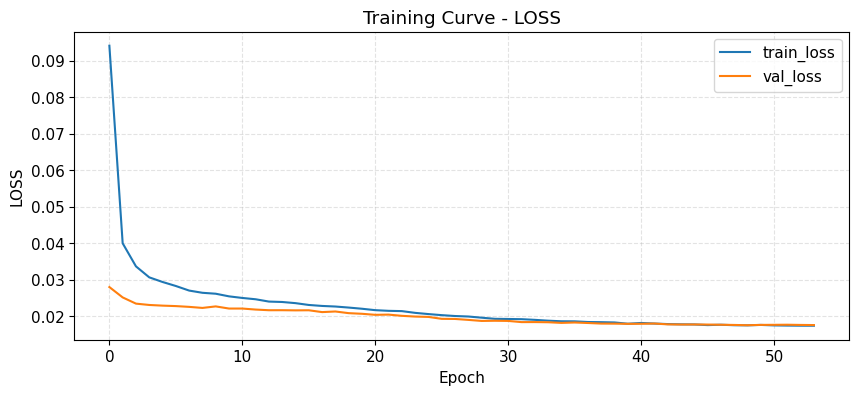

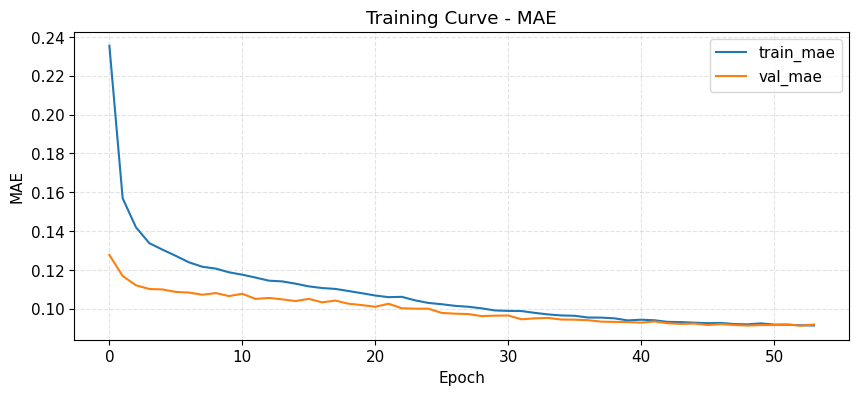

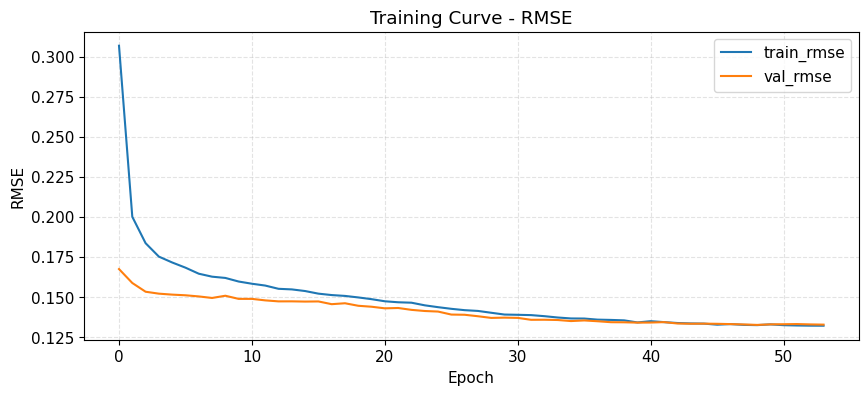

In [ ]:
hist = pd.DataFrame(history.history)
display(hist.tail())

for metric in ["loss", "mae", "rmse"]:
    plt.figure(figsize=(10,4))
    plt.plot(hist[metric], label=f"train_{metric}")
    if f"val_{metric}" in hist.columns:
        plt.plot(hist[f"val_{metric}"], label=f"val_{metric}")
    plt.title(f"Training Curve - {metric.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.show()

## 14) Correct Evaluation (Per Horizon + Overall, in Original Units)

In [ ]:
def flatten_horizon_predictions(y_true_seq: np.ndarray, y_pred_seq: np.ndarray):
    """Flatten (samples, horizon, features) -> (samples*horizon, features)."""
    y_true_flat = y_true_seq.reshape(-1, y_true_seq.shape[-1])
    y_pred_flat = y_pred_seq.reshape(-1, y_pred_seq.shape[-1])
    return y_true_flat, y_pred_flat


def inverse_targets_to_original_units(y_scaled_seq: np.ndarray, y_scaler: MinMaxScaler, target_cols_model: List[str]):
    """Inverse y scaling and postprocess to raw physical target units."""
    shape = y_scaled_seq.shape
    y_flat = y_scaled_seq.reshape(-1, shape[-1])
    y_unscaled_transformed = y_scaler.inverse_transform(y_flat)
    y_raw = inverse_target_postprocess(y_unscaled_transformed, target_cols_model)
    y_raw_seq = y_raw.reshape(shape[0], shape[1], -1)
    return y_raw_seq


def evaluate_direct2(
    model: tf.keras.Model,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
    y_scaler: MinMaxScaler,
    target_cols_model: List[str],
    feature_display_names: List[str],
):
    y_pred_scaled = model.predict(X_eval, verbose=2)

    # Inverse both to ORIGINAL units
    y_true_raw = inverse_targets_to_original_units(y_eval, y_scaler, target_cols_model)
    y_pred_raw = inverse_targets_to_original_units(y_pred_scaled, y_scaler, target_cols_model)

    # Metrics per horizon + feature
    rows = []
    for h in range(y_true_raw.shape[1]):
        for i, fname in enumerate(feature_display_names):
            yt = y_true_raw[:, h, i]
            yp = y_pred_raw[:, h, i]
            rows.append({
                "horizon": h + 1,
                "feature": fname,
                "MAE": mean_absolute_error(yt, yp),
                "RMSE": np.sqrt(mean_squared_error(yt, yp)),
                "R2": r2_score(yt, yp),
            })

    df_metrics = pd.DataFrame(rows)

    # Overall (flatten all horizons + features into one matrix; average feature scales matter, so also report feature-mean)
    y_true_flat, y_pred_flat = flatten_horizon_predictions(y_true_raw, y_pred_raw)

    overall = {
        "MAE_macro_over_features": np.mean([
            mean_absolute_error(y_true_flat[:, i], y_pred_flat[:, i]) for i in range(y_true_flat.shape[1])
        ]),
        "RMSE_macro_over_features": np.mean([
            np.sqrt(mean_squared_error(y_true_flat[:, i], y_pred_flat[:, i])) for i in range(y_true_flat.shape[1])
        ]),
        "R2_macro_over_features": np.mean([
            r2_score(y_true_flat[:, i], y_pred_flat[:, i]) for i in range(y_true_flat.shape[1])
        ]),
    }

    return y_true_raw, y_pred_raw, df_metrics, overall


# Load best checkpoint if saved
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)

y_true_test_raw, y_pred_test_raw, test_metrics_df, test_overall = evaluate_direct2(
    model=model,
    X_eval=X_test,
    y_eval=y_test,
    y_scaler=y_scaler,
    target_cols_model=TARGET_COLS_MODEL,
    feature_display_names=FEATURE_DISPLAY_NAMES,
)

print("Test Overall (macro across features):")
print(test_overall)
display(test_metrics_df)

display(
    test_metrics_df.groupby("horizon")[["MAE", "RMSE", "R2"]].mean().reset_index()
)

display(
    test_metrics_df.pivot(index="feature", columns="horizon", values="R2")
)

13/13 - 0s - 28ms/step
Test Overall (macro across features):
{'MAE_macro_over_features': np.float64(1.850831857749394), 'RMSE_macro_over_features': np.float64(2.785347272529497), 'R2_macro_over_features': np.float64(0.5748208931514195)}


,horizon,feature,MAE,RMSE,R2
0,1,Min Temperature,0.536711,0.676502,0.571257
1,1,Max Temperature,0.964731,1.144413,0.735668
2,1,Rain Sum,3.516374,6.727907,0.282380
3,1,Mean Wind Speed,2.393526,3.160846,0.772365
4,1,Mean Relative Humidity,2.812717,3.703427,0.853878
5,1,Mean Dew Point,0.425174,0.613998,0.806746
6,1,Sunshine Duration,1.250568,2.024564,0.356124
7,2,Min Temperature,0.575522,0.728890,0.501987
8,2,Max Temperature,1.028983,1.231886,0.693748
9,2,Rain Sum,3.802631,7.168559,0.184554


,horizon,MAE,RMSE,R2
0,1,1.699972,2.578808,0.625488
1,2,2.001692,2.970955,0.524151


horizon,1,2
feature,,
Max Temperature,0.735668,0.693748
Mean Dew Point,0.806746,0.704699
Mean Relative Humidity,0.853878,0.807424
Mean Wind Speed,0.772365,0.552628
Min Temperature,0.571257,0.501987
Rain Sum,0.282380,0.184554
Sunshine Duration,0.356124,0.224018


## 15) Plot Sample Predictions (Correctly Aligned)

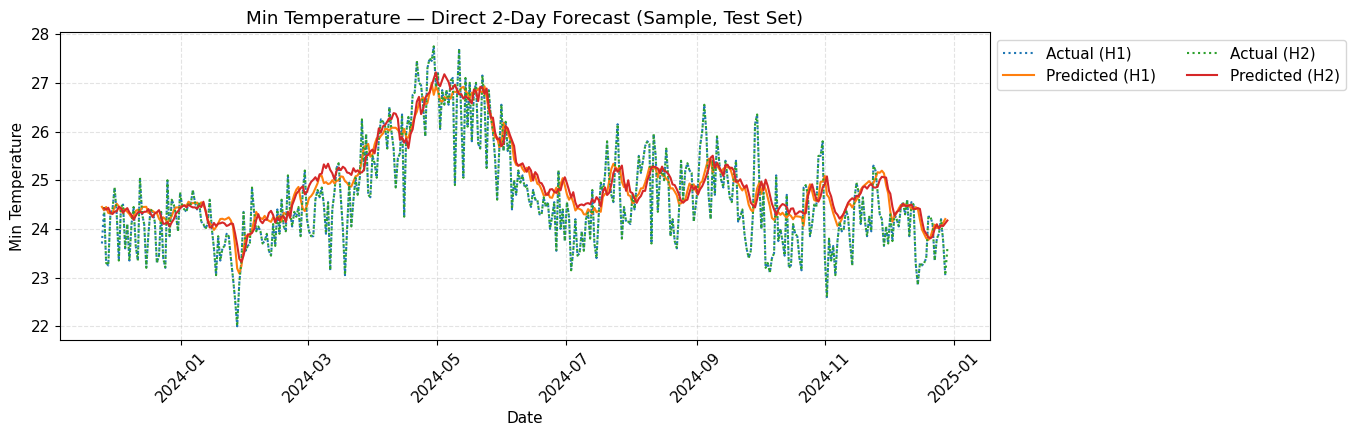

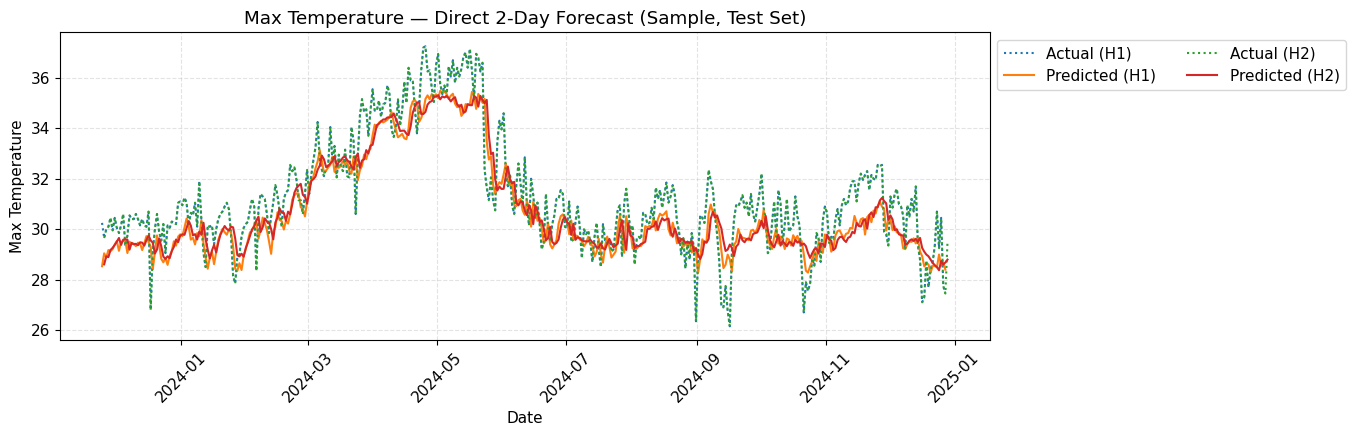

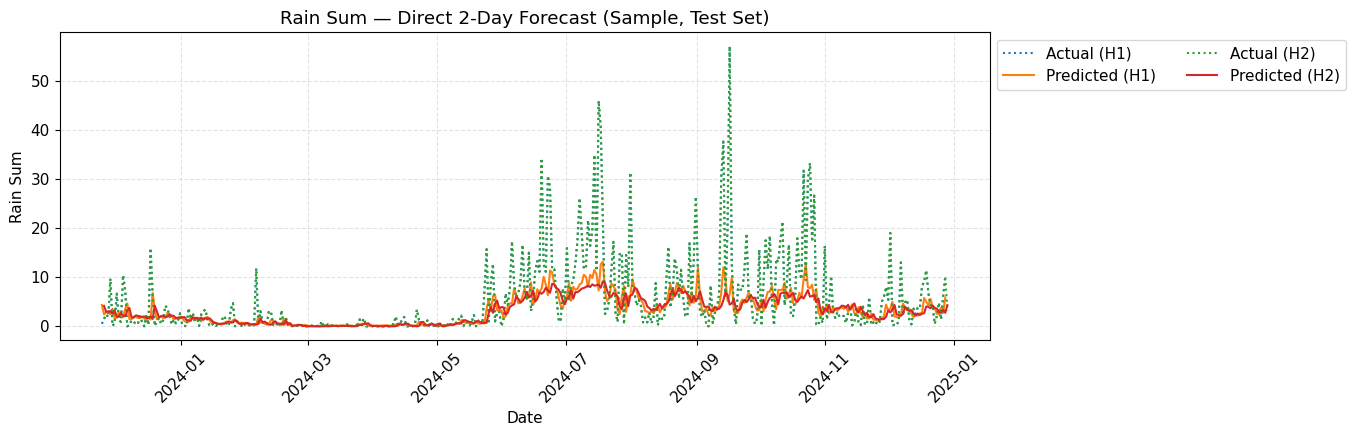

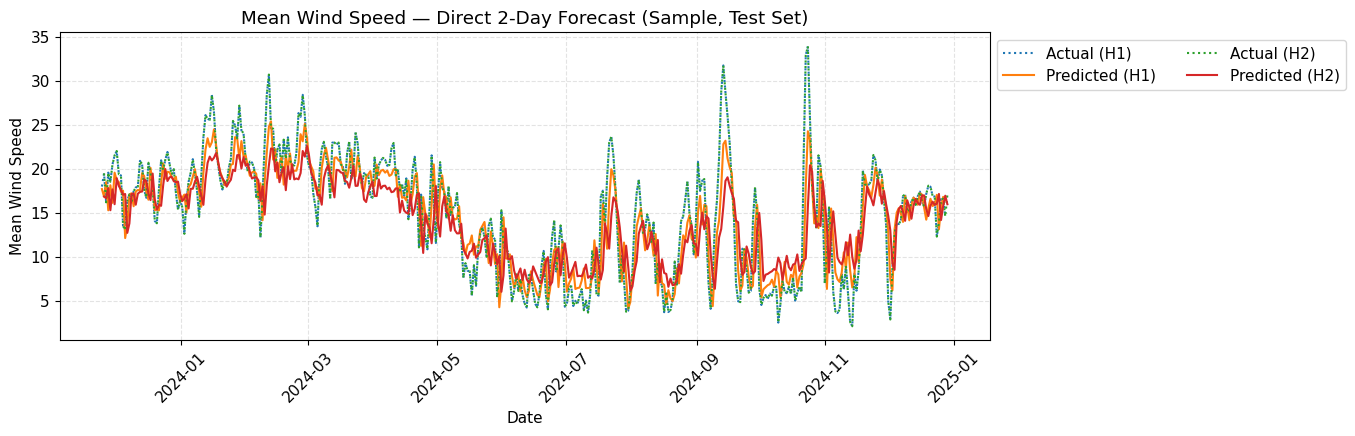

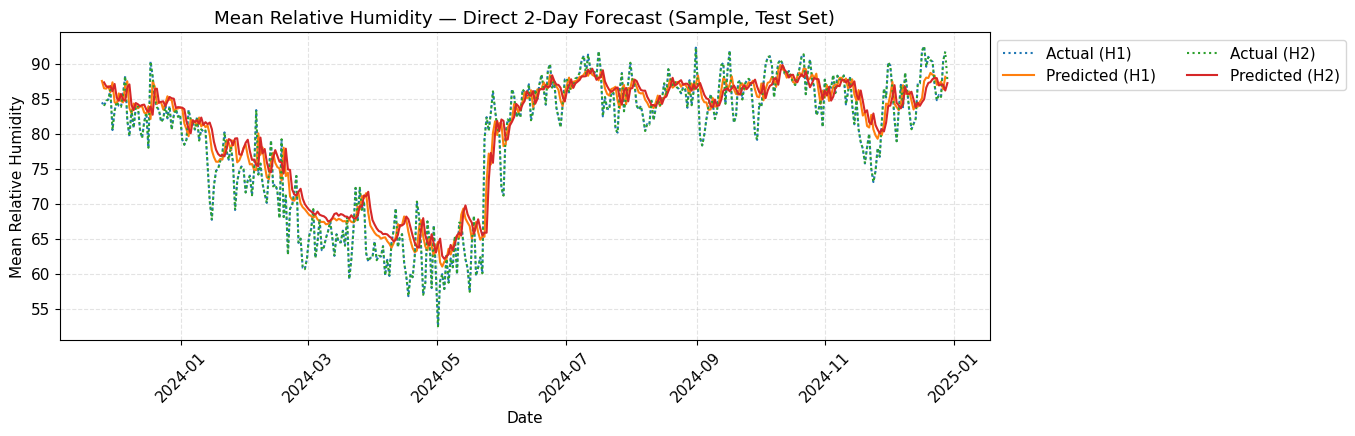

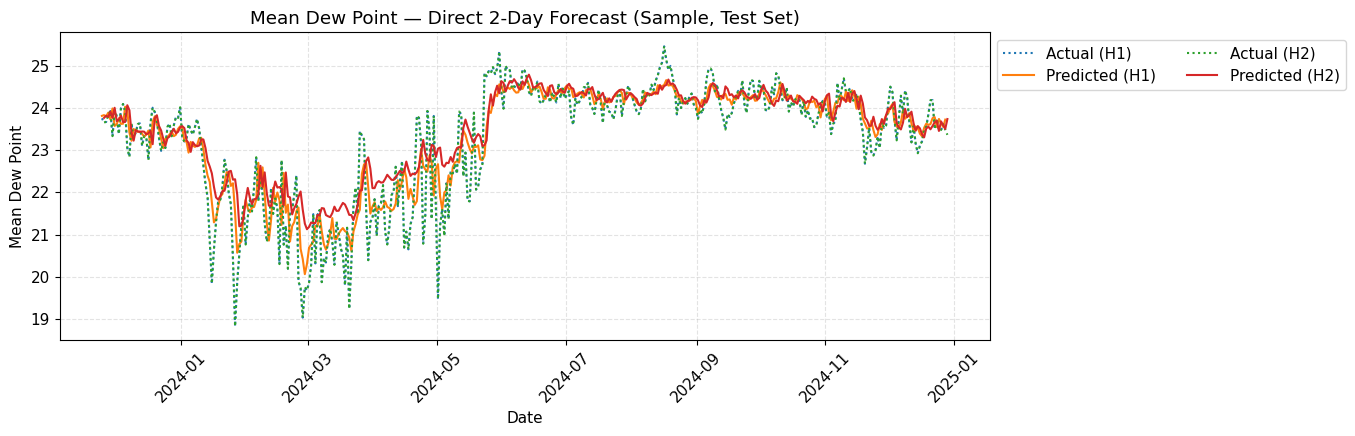

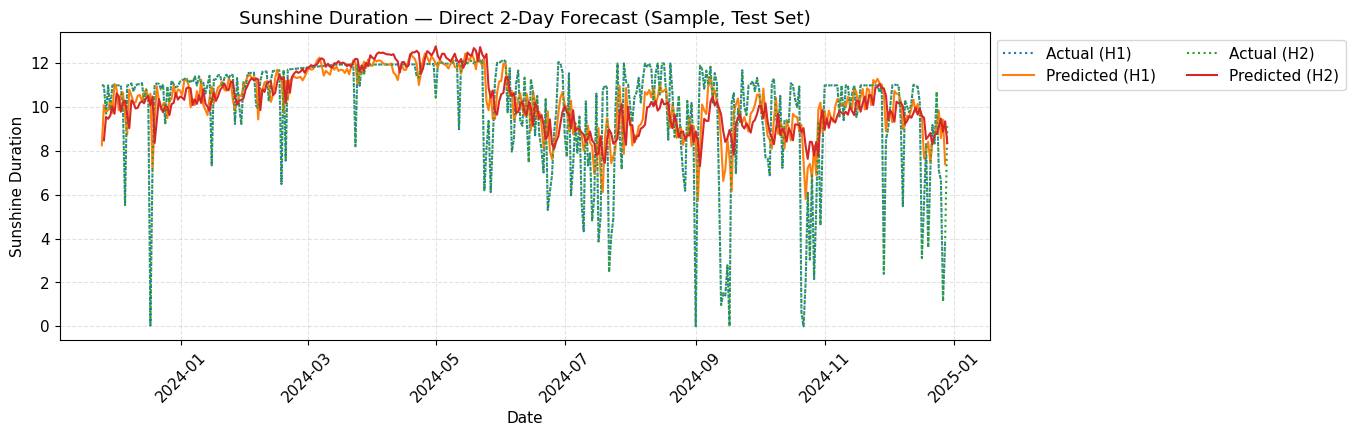

In [ ]:
def plot_sample_direct2_predictions(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: int = 20,
):
    """
    Plot horizon-1 and horizon-2 predictions for selected feature over a subset of sequences.
    Each sequence contributes up to 2 target points.
    """
    n = min(n_sequences_to_plot, len(target_dates_subset))

    rows = []
    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            rows.append({
                "date": pd.to_datetime(target_dates_subset[s][h]),
                "horizon": h + 1,
                "actual": y_true_raw_subset[s, h, feature_idx],
                "predicted": y_pred_raw_subset[s, h, feature_idx],
            })
    plot_df = pd.DataFrame(rows).sort_values(["date", "horizon"])

    plt.figure(figsize=(12,4))
    for h in sorted(plot_df["horizon"].unique()):
        sub = plot_df[plot_df["horizon"] == h]
        plt.plot(sub["date"], sub["actual"], linestyle=":", label=f"Actual (H{h})")
        plt.plot(sub["date"], sub["predicted"], label=f"Predicted (H{h})")

    plt.title(f"{feature_name} — Direct 2-Day Forecast (Sample, Test Set)")
    plt.xlabel("Date")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    plt.legend(ncol=2, bbox_to_anchor=(1,1), loc="upper left")
    plt.show()

# Example plots for a few variables (edit as needed)
for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):  # min temp, max temp, rain, sunshine
    plot_sample_direct2_predictions(td_test, y_true_test_raw, y_pred_test_raw, feat_idx, feature, n_sequences_to_plot=400)

## 16) Save Artifacts (Model + Scalers + Config)

In [ ]:
# Save scalers
joblib.dump(x_scaler, X_SCALER_PATH)
joblib.dump(y_scaler, Y_SCALER_PATH)

# Save config for inference notebook (critical to avoid mismatches)
config = {
    "project_name": PROJ_NAME,
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "timezone": TIMEZONE,
    "target_horizon": TARGET_HORIZON,
    "n_steps": N_STEPS,
    "feature_cols_model": FEATURE_COLS_MODEL,
    "target_cols_model": TARGET_COLS_MODEL,
    "target_cols_raw": TARGET_COLS_RAW,
    "feature_display_names": FEATURE_DISPLAY_NAMES,
    "paths": {
        "model_path": MODEL_PATH,
        "x_scaler_path": X_SCALER_PATH,
        "y_scaler_path": Y_SCALER_PATH,
    },
    "train_date_range": {
        "start": TRAIN_START_DATE,
        "end": TRAIN_END_DATE,
    },
    "tuning": {
        "enabled": RUN_HYPERPARAM_TUNING,
        "method": "KerasTuner BayesianOptimization + custom 5-fold TimeSeriesSplit CV",
        "max_trials": TUNER_MAX_TRIALS if RUN_HYPERPARAM_TUNING else None,
        "tuner_epochs_per_fold": TUNER_EPOCHS if RUN_HYPERPARAM_TUNING else None,
        "tscv_n_splits": TSCV_N_SPLITS if RUN_HYPERPARAM_TUNING else None,
        "tscv_test_size": TSCV_TEST_SIZE if RUN_HYPERPARAM_TUNING else None,
        "best_hyperparameters": best_hparams_dict,
    },
    "notes": {
        "rain_transform": "log1p on rain_sum (target/input)",
        "sunshine_unit": "hours",
        "model_type": "LSTM-only direct multi-horizon (2-day)",
        "evaluation_alignment": "correct (no shifted comparison)",
    }
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print("-", MODEL_PATH)
print("-", X_SCALER_PATH)
print("-", Y_SCALER_PATH)
print("-", CONFIG_PATH)

Saved:
- /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/LSTM_Weather_Forecast_Direct2.keras
- /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/x_scaler.pkl
- /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/y_scaler.pkl
- /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/config.json


## 17) Optional: Simple Walk-Forward Backtest (Validation/Test)

In [ ]:
# This is optional but recommended for thesis-quality reporting.
# It shows how to evaluate in a rolling way on a chosen split without leaking future rows.

def walkforward_direct2_backtest(
    model,
    X_seq: np.ndarray,
    y_seq: np.ndarray,
    target_dates: np.ndarray,
    start_date: Optional[pd.Timestamp],
    end_date: Optional[pd.Timestamp],
    y_scaler: MinMaxScaler,
    target_cols_model: List[str],
    feature_display_names: List[str],
):
    first_target_dates = pd.to_datetime([td[0] for td in target_dates])
    mask = np.ones(len(first_target_dates), dtype=bool)
    if start_date is not None:
        mask &= first_target_dates >= pd.Timestamp(start_date)
    if end_date is not None:
        mask &= first_target_dates <= pd.Timestamp(end_date)

    X_eval = X_seq[mask]
    y_eval = y_seq[mask]
    td_eval = target_dates[mask]

    y_true_raw, y_pred_raw, metrics_df, overall = evaluate_direct2(
        model=model,
        X_eval=X_eval,
        y_eval=y_eval,
        y_scaler=y_scaler,
        target_cols_model=target_cols_model,
        feature_display_names=feature_display_names,
    )
    return td_eval, y_true_raw, y_pred_raw, metrics_df, overall

# Example usage:
# td_bt, y_true_bt, y_pred_bt, bt_metrics_df, bt_overall = walkforward_direct2_backtest(
#     model, X_seq, y_seq, target_dates,
#     start_date=df.index[int(len(df)*0.85)],
#     end_date=df.index[-1],
#     y_scaler=y_scaler,
#     target_cols_model=TARGET_COLS_MODEL,
#     feature_display_names=FEATURE_DISPLAY_NAMES,
# )
# print(bt_overall)
# display(bt_metrics_df.groupby("horizon")[["MAE","RMSE","R2"]].mean())